# Trabalho Final ML 1 — House Prices (Regressão)

Este notebook segue uma pipeline completa de Machine Learning para **regressão**, organizada por seções (Markdown), conforme o desafio:

1. Import de libs  
2. Carregamento da base  
3. Análise Exploratória (EDA)  
4. Pré-processamento (Pipeline + ColumnTransformer)  
5. Treinamento / Validação / Teste  
6. Otimização (Fine Tuning)  
7. Avaliação (métricas de regressão)  
8. Comparativo de performances  
9. Explicabilidade (extra)  
10. Produtização (extra)

**Base esperada:** `data/house_price.csv`  
**Coluna alvo esperada:** `SalePrice`  

> Observação: Como é regressão, itens específicos de classificação (balanceamento de classes, ROC/AUC, matriz de confusão) **não se aplicam**. Aqui usamos RMSE/MAE/R².


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from IPython.display import display

from sklearn.model_selection import train_test_split, KFold, cross_validate, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.compose import TransformedTargetRegressor

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from sklearn.inspection import permutation_importance
import joblib

RANDOM_STATE = 42


## 2) Carregamento da base

- Base House Price: `data/house_price.csv`
- O notebook detecta automaticamente se o arquivo contém:
  - Apenas dados rotulados (todas as linhas com `SalePrice`), ou
  - Base integrada (parte sem `SalePrice`, tratada como “test final”)


In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

base_path = DATA_DIR / "house_price.csv"  # ajuste aqui se o nome for diferente
df = pd.read_csv(base_path)

print("Arquivo:", base_path)
print("Shape:", df.shape)
display(df.head())


Arquivo: c:\Users\TSM08\estudos\0888\python\CAIXAVERSO\PREV\.venv\TrabalhoFinal_ML1\data\house_price.csv
Shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 3) Análise Exploratória (EDA)

### 3.1) Validação de colunas e separação inicial

- Verificamos presença do alvo `SalePrice`
- Se existir parte sem label (`SalePrice` NaN), separamos como `df_test_final`.


In [3]:
TARGET_COL = "SalePrice"
if TARGET_COL not in df.columns:
    raise ValueError(f"Coluna alvo '{TARGET_COL}' não encontrada. Ajuste TARGET_COL.")

df_train = df[df[TARGET_COL].notna()].copy()
df_test_final = df[df[TARGET_COL].isna()].copy()

print("Linhas rotuladas (train):", df_train.shape)
print("Linhas sem label (test final):", df_test_final.shape)

X_full = df_train.drop(columns=[TARGET_COL])
y_full = df_train[TARGET_COL].astype(float)

numeric_features = X_full.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_full.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numéricas:", len(numeric_features))
print("Categóricas:", len(categorical_features))


Linhas rotuladas (train): (1460, 81)
Linhas sem label (test final): (0, 81)
Numéricas: 37
Categóricas: 43


### 3.2) Distribuição do alvo (SalePrice)

- Histograma para ver assimetria  
- Boxplot para outliers

> Nota de modelagem: frequentemente, `SalePrice` é assimétrico; por isso testaremos **transformação log** no alvo via `TransformedTargetRegressor`.


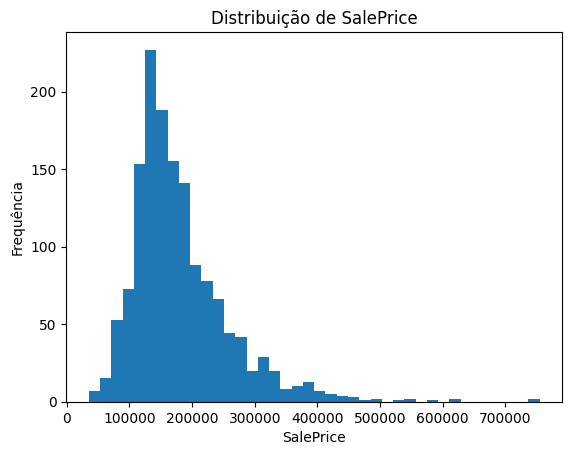

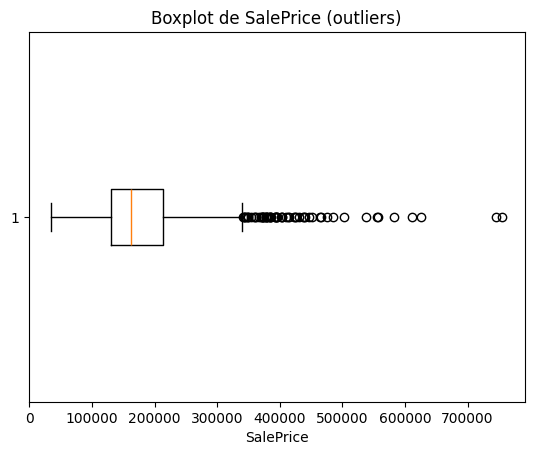

Resumo do target:


count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [4]:
y = y_full

plt.figure()
plt.hist(y, bins=40)
plt.title("Distribuição de SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("Frequência")
plt.show()

plt.figure()
plt.boxplot(y, vert=False)
plt.title("Boxplot de SalePrice (outliers)")
plt.xlabel("SalePrice")
plt.show()

print("Resumo do target:")
display(y.describe())


### 3.3) Dados ausentes (NaN)

- Contagem e percentual de NaNs por coluna


In [5]:
na_counts = X_full.isna().sum().sort_values(ascending=False)
na_percent = (na_counts / len(X_full) * 100).round(2)
missing_df = pd.DataFrame({"na_count": na_counts, "na_%": na_percent})
missing_df = missing_df[missing_df["na_count"] > 0]

print("Colunas com NaN:", missing_df.shape[0])
display(missing_df.head(25))


Colunas com NaN: 19


,na_count,na_%
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageQual,81,5.55
GarageFinish,81,5.55


### 3.4) Correlação (apenas numéricas)

- Top correlações das variáveis numéricas com o target  
- Heatmap das top variáveis numéricas


Top correlações (numéricas) com SalePrice:


SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64

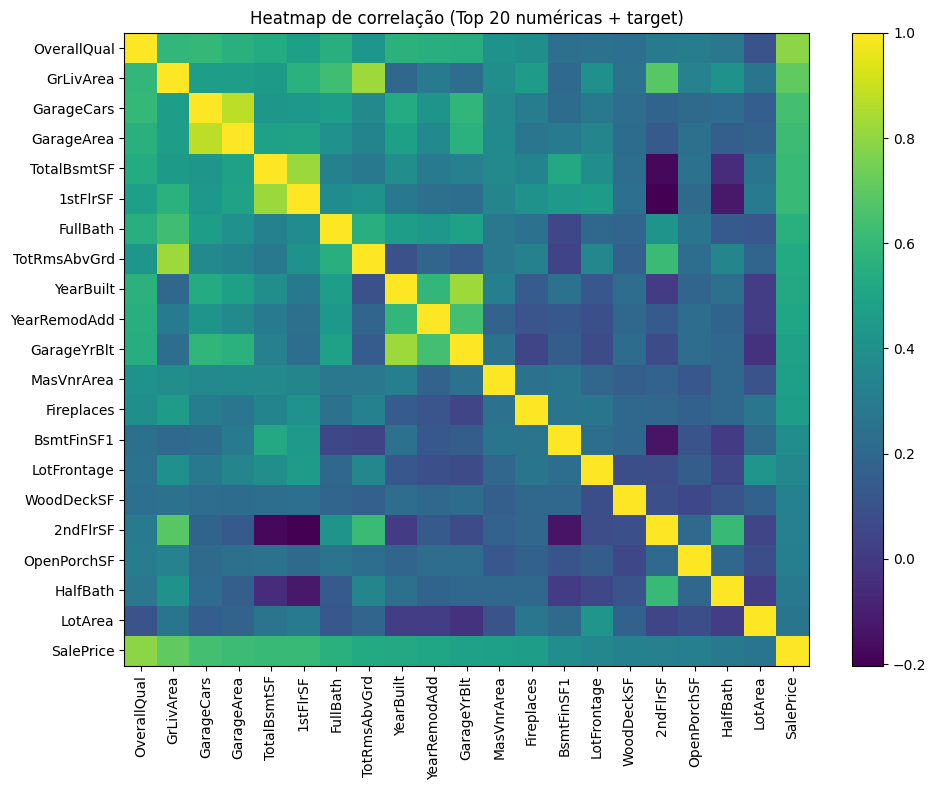

In [6]:
# Correlação somente nas colunas numéricas
df_corr = df_train[numeric_features + [TARGET_COL]].corr(numeric_only=True)
corr_target = df_corr[TARGET_COL].sort_values(ascending=False)

print("Top correlações (numéricas) com SalePrice:")
display(corr_target.head(15))

top_n = 20
top_cols = corr_target.index[1:top_n+1].tolist()
corr_mat = df_train[top_cols + [TARGET_COL]].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(corr_mat.values, aspect="auto")
plt.title(f"Heatmap de correlação (Top {top_n} numéricas + target)")
plt.xticks(range(len(corr_mat.columns)), corr_mat.columns, rotation=90)
plt.yticks(range(len(corr_mat.index)), corr_mat.index)
plt.colorbar()
plt.tight_layout()
plt.show()


### 3.5) Distribuição estatística das features (exemplo)

- Histograma para algumas variáveis numéricas
- Boxplot para visualizar outliers

> Obs.: o dataset tem muitas colunas; aqui mostramos uma amostra das numéricas.


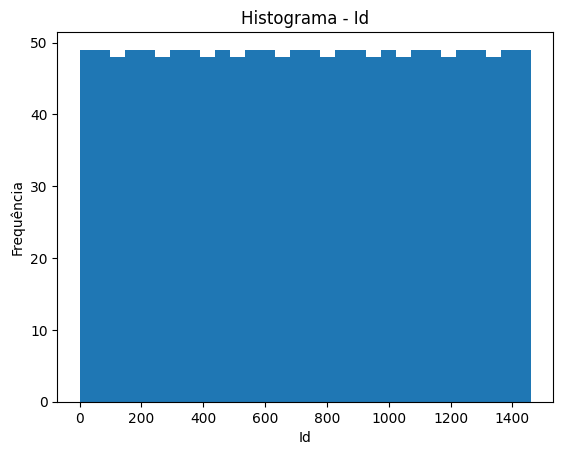

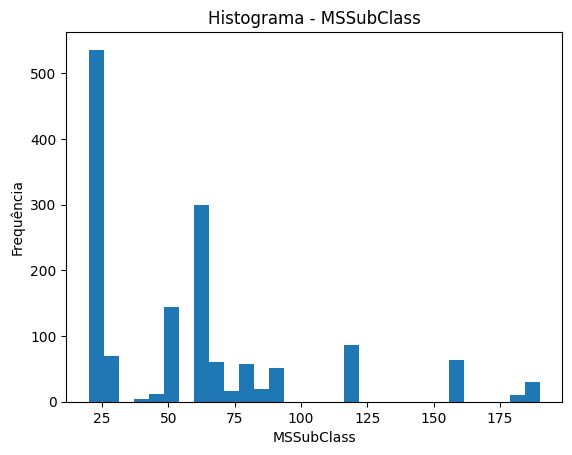

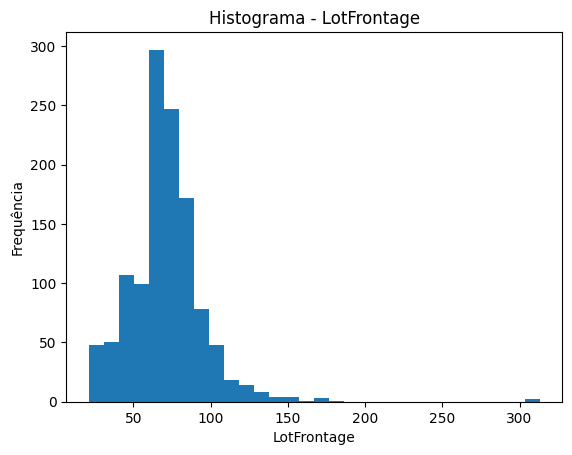

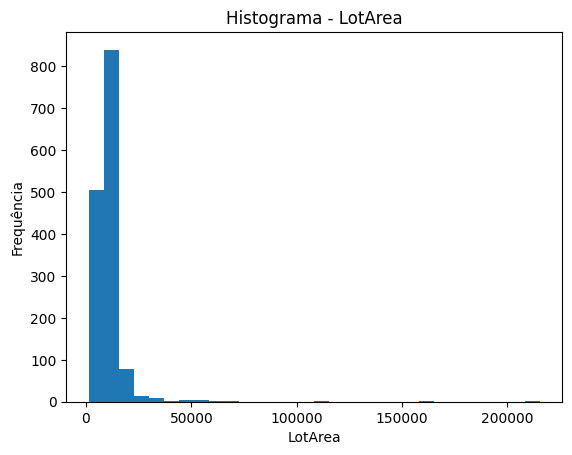

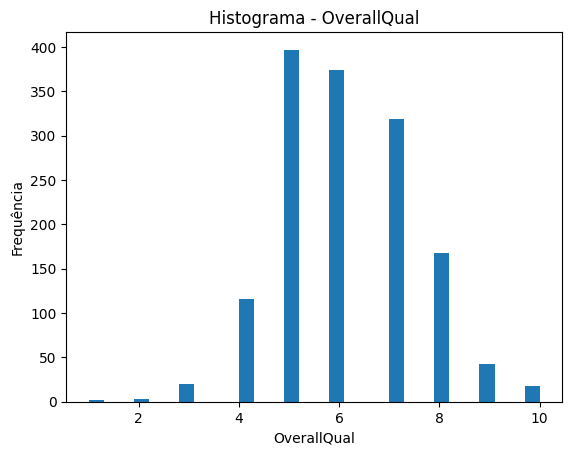

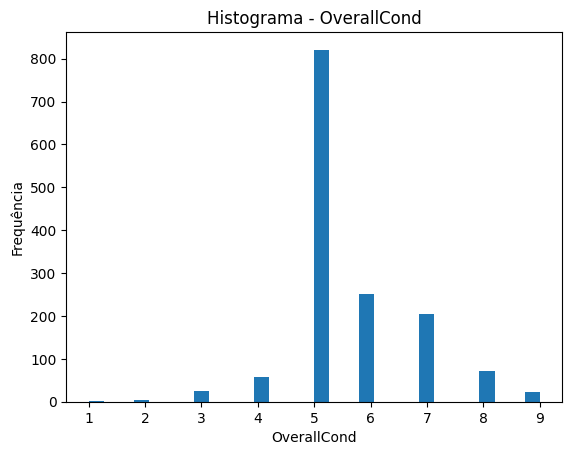

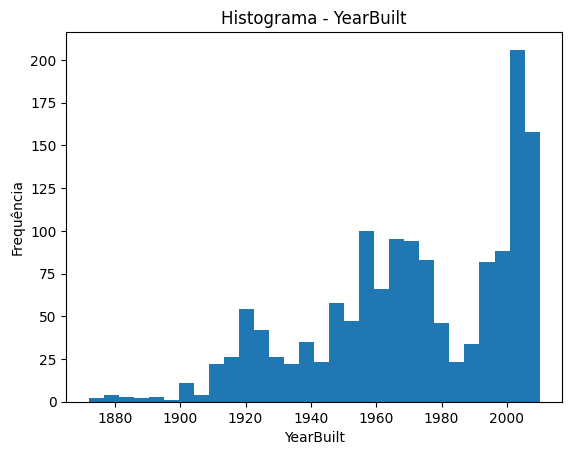

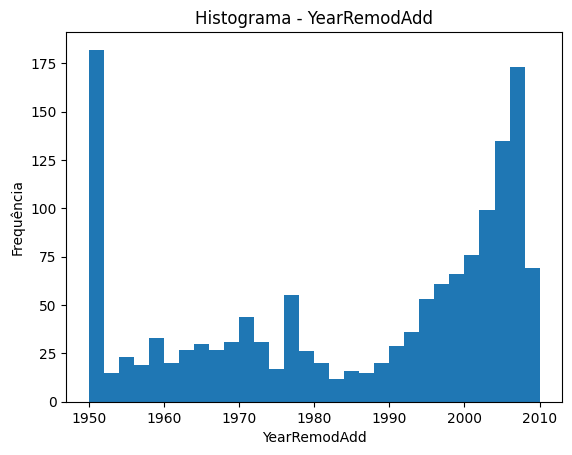

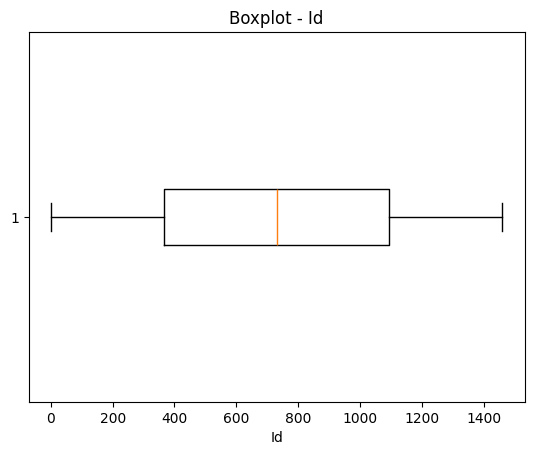

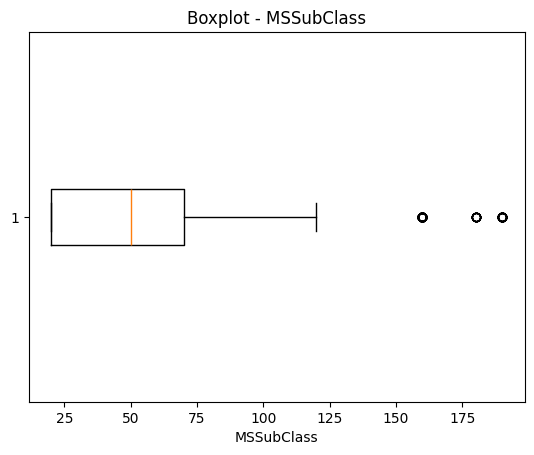

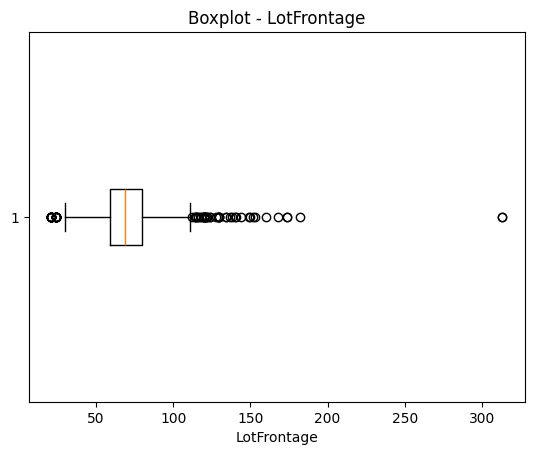

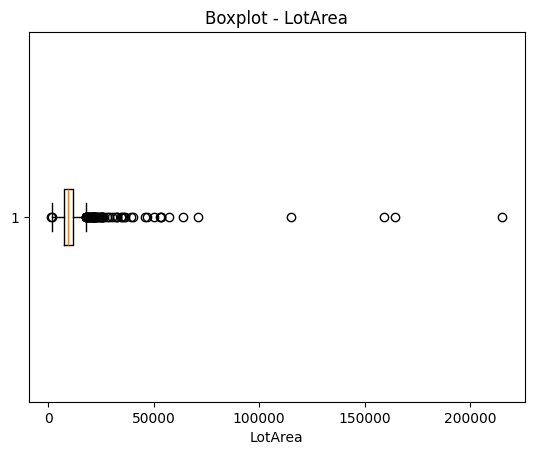

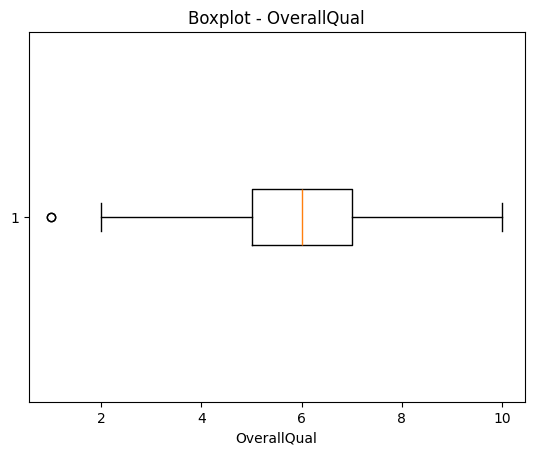

In [7]:
sample_numeric = numeric_features[:8]  # ajuste se quiser
for col in sample_numeric:
    plt.figure()
    plt.hist(df_train[col].dropna(), bins=30)
    plt.title(f"Histograma - {col}")
    plt.xlabel(col)
    plt.ylabel("Frequência")
    plt.show()

for col in sample_numeric[:5]:
    plt.figure()
    plt.boxplot(df_train[col].dropna(), vert=False)
    plt.title(f"Boxplot - {col}")
    plt.xlabel(col)
    plt.show()


## 4) Pré-processamento (Pipeline + ColumnTransformer)

### Estratégia
- Numéricas: imputação (mediana) + padronização (StandardScaler)  
- Categóricas: imputação (mais frequente) + OneHotEncoder  
- Modelo: testaremos múltiplos estimadores dentro da mesma pipeline.

> Importante: imputação e transformações ficam **dentro** do pipeline para evitar vazamento de dados.


In [8]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)


## 5) Treinamento, Validação e Teste

Como é uma base única, fazemos:
- Split treino/validação (holdout)
- Cross-validation no treino para comparação mais robusta

### Métricas usadas (regressão)
- RMSE (raiz do erro quadrático médio)  
- MAE (erro absoluto médio)  
- R² (coeficiente de determinação)


In [12]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

X_train, X_valid, y_train, y_valid = train_test_split(
    X_full, y_full, test_size=0.2, random_state=RANDOM_STATE
)

print("Treino:", X_train.shape, "Validação:", X_valid.shape)

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


Treino: (1168, 80) Validação: (292, 80)


## 6) Modelos candidatos + Comparação

Testaremos diferentes famílias:
- Baseline: Ridge (linear regularizado)
- KNN
- SVR
- Random Forest
- Gradient Boosting

### Transformação do alvo (log1p)
Para lidar com assimetria do `SalePrice`, usamos `TransformedTargetRegressor`, que:
- Treina no alvo transformado (log1p)
- Prediz no espaço original (expm1)
- Mantém avaliação no valor real (R$)


In [13]:
def make_model(estimator, use_log_target=True):
    core = estimator
    if use_log_target:
        core = TransformedTargetRegressor(
            regressor=estimator,
            func=np.log1p,
            inverse_func=np.expm1
        )

    pipe = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", core),
    ])
    return pipe

models = {
    "Ridge_log": make_model(Ridge(random_state=RANDOM_STATE), use_log_target=True),
    "KNN_log": make_model(KNeighborsRegressor(n_neighbors=10), use_log_target=True),
    "SVR_log": make_model(SVR(C=10, epsilon=0.1), use_log_target=True),
    "RandomForest_log": make_model(RandomForestRegressor(
        n_estimators=500, random_state=RANDOM_STATE, n_jobs=-1
    ), use_log_target=True),
    "GradientBoosting_log": make_model(GradientBoostingRegressor(
        random_state=RANDOM_STATE
    ), use_log_target=True),
}


### 6.1) Avaliação rápida no holdout (validação)

Treinamos em `X_train` e avaliamos em `X_valid`.


In [14]:
holdout_rows = []
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_valid)
    holdout_rows.append({
        "modelo": name,
        "RMSE": rmse(y_valid, pred),
        "MAE": mean_absolute_error(y_valid, pred),
        "R2": r2_score(y_valid, pred)
    })

holdout_df = pd.DataFrame(holdout_rows).sort_values("RMSE")
display(holdout_df)

# Salva comparativo do holdout
holdout_df.to_csv(OUTPUT_DIR / "results_holdout.csv", index=False)
print("Salvo:", OUTPUT_DIR / "results_holdout.csv")


,modelo,RMSE,MAE,R2
0,Ridge_log,23865.859466,15750.482742,0.925743
4,GradientBoosting_log,29749.235499,16933.788280,0.884618
3,RandomForest_log,29990.901545,17583.412821,0.882736
2,SVR_log,34703.137798,18506.333498,0.842991
1,KNN_log,40196.842300,22184.254790,0.789346


Salvo: c:\Users\TSM08\estudos\0888\python\CAIXAVERSO\PREV\.venv\TrabalhoFinal_ML1\outputs\results_holdout.csv


### 6.2) Cross-Validation (no treino)

Aqui comparamos por CV para reduzir variância do holdout.


In [16]:
cv_rows = []
for name, pipe in models.items():
    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "mse": "neg_mean_squared_error",
            "mae": "neg_mean_absolute_error",
            "r2": "r2"
        },
        n_jobs=-1,
        return_train_score=False
    )

    rmse_scores = np.sqrt(-scores["test_mse"])

    cv_rows.append({
        "modelo": name,
        "CV_RMSE_mean": rmse_scores.mean(),
        "CV_RMSE_std":  rmse_scores.std(),
        "CV_MAE_mean":  (-scores["test_mae"]).mean(),
        "CV_R2_mean":    scores["test_r2"].mean(),
    })

cv_df = pd.DataFrame(cv_rows).sort_values("CV_RMSE_mean")
display(cv_df)

cv_df.to_csv(OUTPUT_DIR / "results_models.csv", index=False)
print("Salvo:", OUTPUT_DIR / "results_models.csv")


,modelo,CV_RMSE_mean,CV_RMSE_std,CV_MAE_mean,CV_R2_mean
4,GradientBoosting_log,27991.645943,6030.582846,16282.063051,0.865080
3,RandomForest_log,31256.049050,4461.966881,18475.139282,0.834207
2,SVR_log,33213.722856,6444.018028,17902.177360,0.812148
1,KNN_log,37728.429174,3362.589396,22114.935240,0.759442
0,Ridge_log,42935.829905,26027.452491,17693.108983,0.606184


Salvo: c:\Users\TSM08\estudos\0888\python\CAIXAVERSO\PREV\.venv\TrabalhoFinal_ML1\outputs\results_models.csv


## 7) Otimização de Modelos (Fine Tuning)

Vamos tunar o melhor candidato por CV (normalmente RandomForest ou GradientBoosting).
Aqui faremos `RandomizedSearchCV` no RandomForest.

> Ajuste `n_iter` se quiser mais busca (custa mais tempo).


In [17]:
rf_base = make_model(RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1), use_log_target=True)

param_dist = {
    # parâmetros do regressor interno
    "model__regressor__n_estimators": [300, 500, 800, 1200],
    "model__regressor__max_depth": [None, 8, 12, 16, 24],
    "model__regressor__min_samples_split": [2, 5, 10],
    "model__regressor__min_samples_leaf": [1, 2, 4],
    "model__regressor__max_features": ["sqrt", "log2", 0.5],
}

search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=25,
    scoring="neg_mean_squared_error",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print("Melhor RMSE (CV):", float(np.sqrt(-search.best_score_)))
print("Melhores params:")
display(search.best_params_)



Fitting 5 folds for each of 25 candidates, totalling 125 fits
Melhor RMSE (CV): 30632.757807436807
Melhores params:


{'model__regressor__n_estimators': 1200,
 'model__regressor__min_samples_split': 2,
 'model__regressor__min_samples_leaf': 1,
 'model__regressor__max_features': 0.5,
 'model__regressor__max_depth': None}

## 8) Avaliação final do RandomForest tunado no holdout

Avaliamos o melhor pipeline do tuning no conjunto de validação.


In [18]:
best_model = search.best_estimator_

pred_valid = best_model.predict(X_valid)

final_metrics = {
    "RMSE": rmse(y_valid, pred_valid),
    "MAE": mean_absolute_error(y_valid, pred_valid),
    "R2": r2_score(y_valid, pred_valid),
}
print("Métricas no holdout (validação):")
display(final_metrics)

# Serializa o melhor modelo (extra)
model_path = OUTPUT_DIR / "best_model.joblib"
joblib.dump(best_model, model_path)
print("Modelo salvo em:", model_path)


Métricas no holdout (validação):


{'RMSE': 29937.53043696604,
 'MAE': 17063.376187133417,
 'R2': 0.8831528536785733}

Modelo salvo em: c:\Users\TSM08\estudos\0888\python\CAIXAVERSO\PREV\.venv\TrabalhoFinal_ML1\outputs\best_model.joblib


## 9) Explicabilidade (Extra)

Como temos OneHotEncoder, a importância pode ficar grande.
Aqui usamos **Permutation Importance** no holdout para ver quais variáveis mais impactam o erro.

> Dependendo do tamanho do dataset e do número de colunas após OneHot, pode demorar.


,feature,importance_mean
0,num__BsmtFullBath,0.280627
1,cat__LotShape_IR1,0.149931
2,cat__LandSlope_Gtl,0.050767
3,cat__MSZoning_FV,0.028864
4,cat__Street_Pave,0.026716
5,num__FullBath,0.021448
6,cat__LandSlope_Mod,0.018612
7,num__OverallQual,0.015894
8,num__GarageArea,0.013442
9,num__EnclosedPorch,0.013429


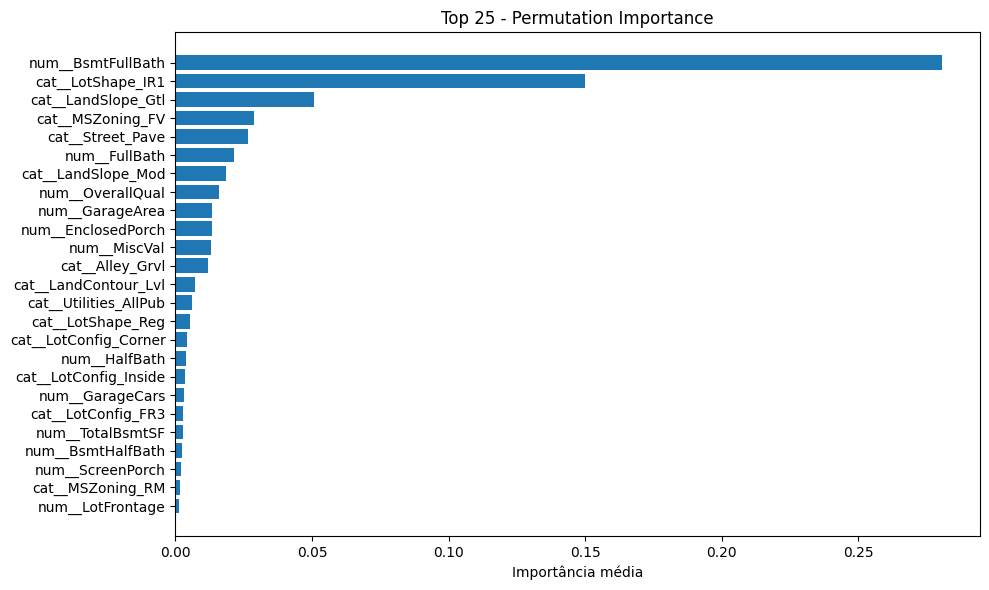

In [19]:
# Tenta recuperar nomes das features após o preprocess
try:
    feature_names = best_model.named_steps["preprocess"].get_feature_names_out()
except Exception as e:
    feature_names = None
    print("Não consegui obter nomes das features:", e)

# Permutation importance (em um subset para velocidade)
X_valid_subset = X_valid.sample(n=min(300, len(X_valid)), random_state=RANDOM_STATE)
y_valid_subset = y_valid.loc[X_valid_subset.index]

result = permutation_importance(
    best_model, X_valid_subset, y_valid_subset,
    n_repeats=8, random_state=RANDOM_STATE, n_jobs=-1
)

importances = result.importances_mean
idx = np.argsort(importances)[::-1][:25]

top_imp = pd.DataFrame({
    "feature": [feature_names[i] if feature_names is not None else str(i) for i in idx],
    "importance_mean": importances[idx]
})

display(top_imp)

plt.figure(figsize=(10, 6))
plt.barh(top_imp["feature"][::-1], top_imp["importance_mean"][::-1])
plt.title("Top 25 - Permutation Importance")
plt.xlabel("Importância média")
plt.tight_layout()
plt.show()


## Conclusões (Storytelling)

### Problema
Prever o preço de venda de imóveis (`SalePrice`) com base em múltiplas características do imóvel (numéricas e categóricas).

### O que fizemos
- EDA para entender distribuição do alvo, ausências e correlações
- Pipeline com ColumnTransformer (sem vazamento):
  - numéricas: imputação (mediana) + padronização
  - categóricas: imputação (mais frequente) + One-Hot Encoding
- Transformação do alvo com log1p (TransformedTargetRegressor)
- Treinamento e comparação de modelos via holdout e cross-validation
- Fine tuning com RandomizedSearchCV (RandomForest) e explicabilidade com Permutation Importance (extra)

### Resultados
- Reportados em `outputs/results_models.csv` (CV) e `outputs/results_holdout.csv` (holdout)
- Melhor modelo salvo em `outputs/best_model.joblib`

### Próximos passos
- Tunar também o modelo campeão no CV (ex.: GradientBoosting) e testar HistGradientBoostingRegressor
- Explorar engenharia/seleção de features e validação com splits alternativos
